In [ ]:
pip install pandas matplotlib seaborn scipy

In [15]:
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [16]:
# Load the data from .mat files
def load_mat_data(file_path):
    data = scipy.io.loadmat(file_path)
    return data['On_time_bound_single_filtered'].flatten()

In [17]:
# File paths (replace these with your actual file paths)
file_path_rfa1 = '/Users/masoomeshafiee/Desktop/Bound2learn/Bound2Learn/Data/Rfa1_long_549_500msInt_5%_Aug10_batch/AnalysisMLnew_S_Time_Int0.5_240_Trkwd_3_datpt_4_Spt_Thr_1.6/Analysis Files-trunc1.5/Trackmate_On_time_bound_single_filtered.mat'
file_path_rad53 = '/Users/masoomeshafiee/Desktop/Bound2learn/Bound2Learn/Data/20231011_Rfa1_long_549_500msint_5%_CPT_10uM_batch/AnalysisMLnew_S_Time_Int0.5_280_Trkwd_3_datpt_4_Spt_Thr_1.6/Analysis Files/Trackmate_On_time_bound_single_filtered.mat'

In [10]:
# Load the data
rfa1_data = load_mat_data(file_path_rfa1)
rad53_data = load_mat_data(file_path_rad53)


In [18]:
# Prepare the data for plotting
# if you have more proteins or condition to plot you need to input it in the concatenate
df = pd.DataFrame({
    'Bound Time': np.concatenate([rfa1_data, rad53_data]),
    'Protein': ['Rfa1'] * len(rfa1_data) + ['Rad53'] * len(rad53_data)
})

In [19]:
# Custom colors for the violin plots
protein_colors = {
    'Rfa1': 'purple',
    'Rad53': 'mediumorchid',
    'H3': 'saddlebrown'
}


/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


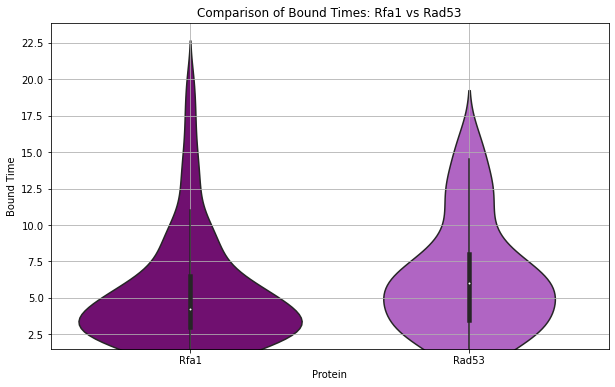

In [22]:
# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Protein', y='Bound Time', data=df, palette = protein_colors)
plt.title('Comparison of Bound Times: Rfa1 vs Rad53')
plt.xlabel('Protein')
plt.ylabel('Bound Time')
# Set the y-axis to start from the minimum positive value to avoid touching zero
plt.ylim(bottom=min([np.min(rfa1_data[rfa1_data > 0]), 
                     np.min(rad53_data[rad53_data > 0])]))
plt.grid(True)
plt.show()